<a href="https://colab.research.google.com/github/Ulturaa/CSMODEL_MCO/blob/main/TotallyStats_MCO2.ipynb%20%2B%20D" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# __`Education & Career Success`__

# 1) Abstract

The study explores the factors that contribute to career success using the Education & Career Success dataset by Adil Shamim from Kaggle. The dataset obtained includes information on student demographics, academic performance, practical experience, skills, and career outcomes. Our research question targets to investigate the main contributing factors to higher starting salaries and overall job satisfaction after graduation.

To examine the relationships between academic track, academic performance, practical experience, salary, job offers, work-life balance, and career satisfaction, Exploratory Data Analysis (EDA) was conducted. The results of the analysis imply that STEM graduates receive the highest starting salaries, followed by ABM, HUMSS, and then A&D graduates. The results also suggest that practical experience has a stronger relationship with job offers than only academic performance. Additionally, higher starting salaries were associated with greater career satisfaction, while work-life balance showed a more complex relationship with both salary and satisfaction.

Overall, the findings highlight the importance of practical experience and skill development alongside academic achievement in contributing to career success and improved employment outcomes.


---

# 2) Dataset Description

The "Education & Career Success" dataset is collected by Adil Shamim found on Kaggle. The dataset includes data collected from 400 anonymized student records. The purpose of this dataset is to explore how students' academic achievements, skills, and extracurricular activities translate into real-world career outcomes. The key features are: <br><br>
- **`Student Demographics`**
    - **Student_ID** — Unique alphanumeric identifier for each student (ensures privacy while enabling record linkage)
    - **Age** — Student's age in whole years at graduation or data collection *(range: 18–30)*
    - **Gender** — Self-reported gender identity: `"Male"`, `"Female"`, or `"Other"`
- **`Academic Performance`**
    - **High_School_GPA** — Cumulative high school GPA *(scale: 2.0–4.0)*
    - **SAT_Score** — Total SAT score *(range: 900–1600)*
    - **University_GPA** — Cumulative undergraduate GPA *(scale: 2.0–4.0)*
    - **Field_of_Study** — Major or academic discipline (e.g., `"Computer Science"`, `"Medicine"`, `"Business"`)
- **`Skills & Extracurriculars`**
    - **Internships_Completed** — Number of formal internships completed during college *(range: 0–4)*
    - **Projects_Completed** — Count of significant academic or personal projects finished *(range: 0–9)*
    - **Certifications** — Number of industry-recognized certificates earned beyond coursework *(range: 0–5)*
    - **Soft_Skills_Score** — Instructor- or peer-rated measure of communication, teamwork, and leadership *(scale: 1–10)*
    - **Networking_Score** — Quantitative assessment of professional networking activity *(scale: 1–10)*
- **`Career Outcomes`**
    - **Job_Offers** — Total distinct full-time job offers received within six months of graduation *(range: 0–5)*
    - **Starting_Salary** — Annual base salary (USD) for first full-time position *(range: $25,000–$150,000)*
    - **Career_Satisfaction** — Self-reported satisfaction with first job *(1 = very dissatisfied, 10 = very satisfied)*
    - **Years_to_Promotion** — Years from hire date to next-level promotion *(range: 1–5)*
    - **Current_Job_Level** — Career stage at data collection: `"Entry"`, `"Mid"`, `"Senior"`, or `"Executive"`
    - **Work_Life_Balance** — Self-assessed work-life balance *(1 = poor, 10 = excellent)*
    - **Entrepreneurship** — Whether the individual founded or co-founded a business (`"Yes"` or `"No"`)


- **`Possible Limitations`**
    - The dataset does not specify the geographic location or demographic composition of the participants, making it difficult to assess its representativeness. Additionally, variables such as Networking_Score lack a documented measurement methodology, which may affect the interpretation of the results.

Link to dataset: __[Education & Career Success](https://www.kaggle.com/datasets/adilshamim8/education-and-career-success?fbclid=IwZXh0bgNhZW0CMTAAYnJpZBExUjlIanJLenJCazVxbUR0eHNydGMGYXBwX2lkEDIyMjAzOTE3ODgyMDA4OTIAAR4QS3HWekgmCm9A-ZttCXnKceAdPbixPsDSeC8o3lGVJva-9pHFG7ohKL_CHQ_aem_oOsJTFvZEOXoLMiK3tuVgQ)__


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
from scipy.stats import shapiro, levene, ttest_ind, f_oneway


try:
    # Load dataset
    # If in colab, prompt file upload
    # Else, find dataset in the same folder
    try:
        from google.colab import files
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

    if IN_COLAB:
        from google.colab import files
        uploaded = files.upload()
        filename = next(iter(uploaded))
    else:
        filename = 'education_career_success.csv'

    ecs_df = pd.read_csv(
        filename,
        index_col="Student_ID"
    )

    print(f"Successfully loaded {filename}")

except FileNotFoundError:
    print("File not found.", file=sys.stderr)

except pd.errors.EmptyDataError:
    print("CSV is empty.", file=sys.stderr)

except pd.errors.ParserError:
    print("Invalid CSV format.", file=sys.stderr)

except Exception as e:
    print(f"Error: {e}", file=sys.stderr)

else:
    display(ecs_df.head())

Saving education_career_success (1).csv to education_career_success (1).csv
Successfully loaded education_career_success (1).csv


,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
Student_ID,,,,,,,,,,,,,,,,,,
S001,22,Male,3.8,1450,3.6,Computer Science,3,7,2,8,7,3,85000,8,2,Mid,7,No
S002,24,Female,3.6,1380,3.4,Business,2,5,3,7,6,2,65000,7,3,Mid,6,No
S003,21,Male,3.9,1520,3.8,Engineering,4,9,4,9,8,4,120000,9,1,Senior,6,No
S004,23,Female,3.5,1300,3.2,Psychology,1,3,1,6,5,1,48000,6,4,Entry,8,No
S005,25,Male,3.7,1420,3.5,Medicine,2,6,2,8,7,3,95000,8,2,Mid,5,No


In [2]:
# Overview description of the table
ecs_df.describe(percentiles=None, include=None, exclude=None)

,Age,High_School_GPA,SAT_Score,University_GPA,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Work_Life_Balance
count,400.000000,400.00000,400.000000,400.000000,400.000000,400.00000,400.0000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,23.000000,3.62425,1388.600000,3.441000,2.500000,6.23500,2.6250,7.932500,6.932500,2.740000,87562.500000,7.792500,2.915000,6.412500
std,1.415985,0.18795,114.311889,0.285522,1.061988,1.90232,1.2702,1.314253,1.318062,1.355357,29685.419892,1.372645,1.340622,0.929788
min,21.000000,3.20000,1160.000000,2.800000,0.000000,2.00000,0.0000,5.000000,4.000000,0.000000,31000.000000,5.000000,1.000000,5.000000
25%,22.000000,3.50000,1300.000000,3.200000,2.000000,5.00000,2.0000,7.000000,6.000000,2.000000,68000.000000,7.000000,2.000000,6.000000
50%,23.000000,3.60000,1380.000000,3.450000,3.000000,6.00000,3.0000,8.000000,7.000000,3.000000,84000.000000,8.000000,3.000000,6.000000
75%,24.000000,3.80000,1480.000000,3.700000,3.000000,8.00000,3.0000,9.000000,8.000000,4.000000,105250.000000,9.000000,4.000000,7.000000
max,25.000000,3.90000,1580.000000,4.000000,4.000000,9.00000,5.0000,10.000000,9.000000,5.000000,152000.000000,10.000000,5.000000,9.000000


---

# 3) Data Cleaning and Preprocessing

For the data cleaning and preprocessing, the dataset we have obtained is already clean and well-structured. However, we performed some basic checks to ensure there are no missing values or inconsistencies in the data.

In [ ]:
ecs_df.isnull().sum()

Age                      0
Gender                   0
High_School_GPA          0
SAT_Score                0
University_GPA           0
Field_of_Study           0
Internships_Completed    0
Projects_Completed       0
Certifications           0
Soft_Skills_Score        0
Networking_Score         0
Job_Offers               0
Starting_Salary          0
Career_Satisfaction      0
Years_to_Promotion       0
Current_Job_Level        0
Work_Life_Balance        0
Entrepreneurship         0
dtype: int64

From the output above, we can conclude that there were no missing values in the dataset.

In [ ]:
ecs_df.duplicated().sum()

np.int64(232)

From the result, there seems to be 232 observed duplicates. To further inspect the duplicates:

In [ ]:
dup_rows = ecs_df[ecs_df.duplicated(keep=False)]
dup_rows.sort_values(list(ecs_df.columns)).head(20)

,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
Student_ID,,,,,,,,,,,,,,,,,,
S154,21,Female,3.40,1260,3.10,Psychology,1,4,1,6,5,1,56000,6,5,Entry,8,No
S224,21,Female,3.40,1260,3.10,Psychology,1,4,1,6,5,1,56000,6,5,Entry,8,No
S284,21,Female,3.40,1260,3.10,Psychology,1,4,1,6,5,1,56000,6,5,Entry,8,No
S354,21,Female,3.40,1260,3.10,Psychology,1,4,1,6,5,1,56000,6,5,Entry,8,No
S374,21,Female,3.40,1260,3.10,Psychology,1,4,1,6,5,1,56000,6,5,Entry,8,No
S394,21,Female,3.40,1260,3.10,Psychology,1,4,1,6,5,1,56000,6,5,Entry,8,No
S114,21,Female,3.50,1300,3.20,Marketing,2,5,2,7,6,2,64000,7,4,Mid,7,No
S184,21,Female,3.50,1300,3.20,Marketing,2,5,2,7,6,2,64000,7,4,Mid,7,No
S244,21,Female,3.50,1300,3.20,Marketing,2,5,2,7,6,2,64000,7,4,Mid,7,No


Upon inspection, these duplicates corresponded to repeated student profiles with identical attributes but different Student_ID values. Since the dataset appears to be synthetically generated, these repeated profiles were treated as part of the dataset design rather than data-entry errors.

Additionally, we created tracks for fields of study, STEM, ABM, HUMSS and A&D as a form of feature engineering.

Create a new column for **"Track"**

In [3]:
track_map = {
    'Computer Science': 'STEM',
    'Engineering': 'STEM',
    'Medicine': 'STEM',
    'Nursing': 'STEM',

    'Business': 'ABM',
    'Finance': 'ABM',
    'Marketing': 'ABM',

    'Law': 'HUMSS',
    'Psychology': 'HUMSS',
    'Education': 'HUMSS',

    'Arts': 'A&D'
}

ecs_df['Track'] = ecs_df['Field_of_Study'].map(track_map)

#counts how many students are under each track
ecs_df['Track'].value_counts()

,count
Track,
STEM,145
ABM,121
HUMSS,102
A&D,32


---
# 4) Exploratory Data Analysis (EDA)

The given dataset contains various columns that can be analyzed to understand the relationships between education and career success. We have our main research question:

***"What are the main contributing factors for a high salary and overall job satisfaction?"***

As part of the exploratory data analysis, and to answer our main research question, the following questions were formed:

## EDA Question 1
How does average starting salary differ among academic tracks;
1. STEM (Science, Technology, Engineering, and Mathematics)
2. ABM (Accountancy, Business, and Management)
3. HUMSS (Humanities and Social Sciences)
4. A&D (Arts and Design)


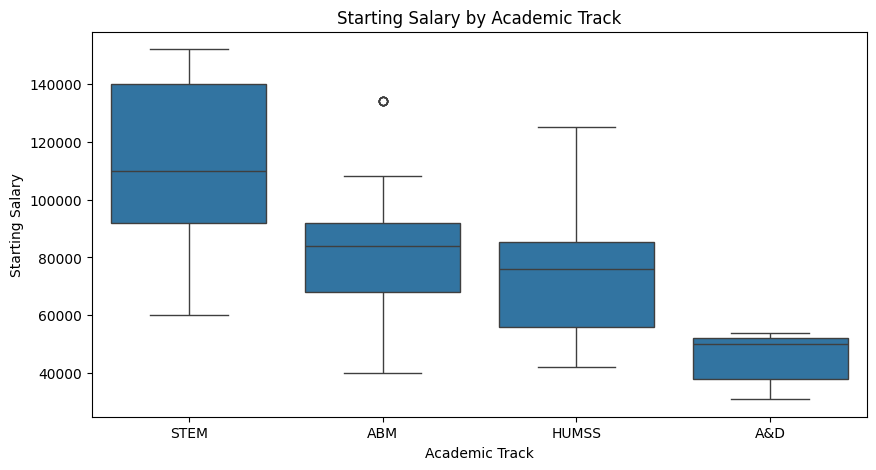

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=ecs_df,
    x='Track',
    y='Starting_Salary'
)

plt.title('Starting Salary by Academic Track')
plt.xlabel('Academic Track')
plt.ylabel('Starting Salary')

plt.show()

### EDA Question 1 Findings

The plot helps visualize the distribution of starting salaries across academic tracks. STEM graduates tend to receive the highest starting salaries, with a median salary of approximately 110,000 USD and an upper range reaching around 150,000 USD. This suggests that careers associated with STEM fields generally offer higher initial compensation than other tracks.

ABM has the second-highest median salary at approximately 84,000 USD. Most salaries are concentrated between 70,000 USD and 90,000 USD, indicating a relatively consistent salary distribution compared to STEM.

HUMSS ranks third among the four tracks, with a median salary of approximately 76,000 USD and a wider salary range, indicating greater variability in career outcomes.

A&D graduates have the lowest median starting salary at approximately 50,000 USD, suggesting that careers in arts and design generally offer lower initial compensation compared to the other academic tracks.

---
## EDA Question 2
What has a bigger impact on the number of job offers received: academic performance (University_GPA) or practical experience (Internships_Completed)? How does this relationship behave across different academic tracks?

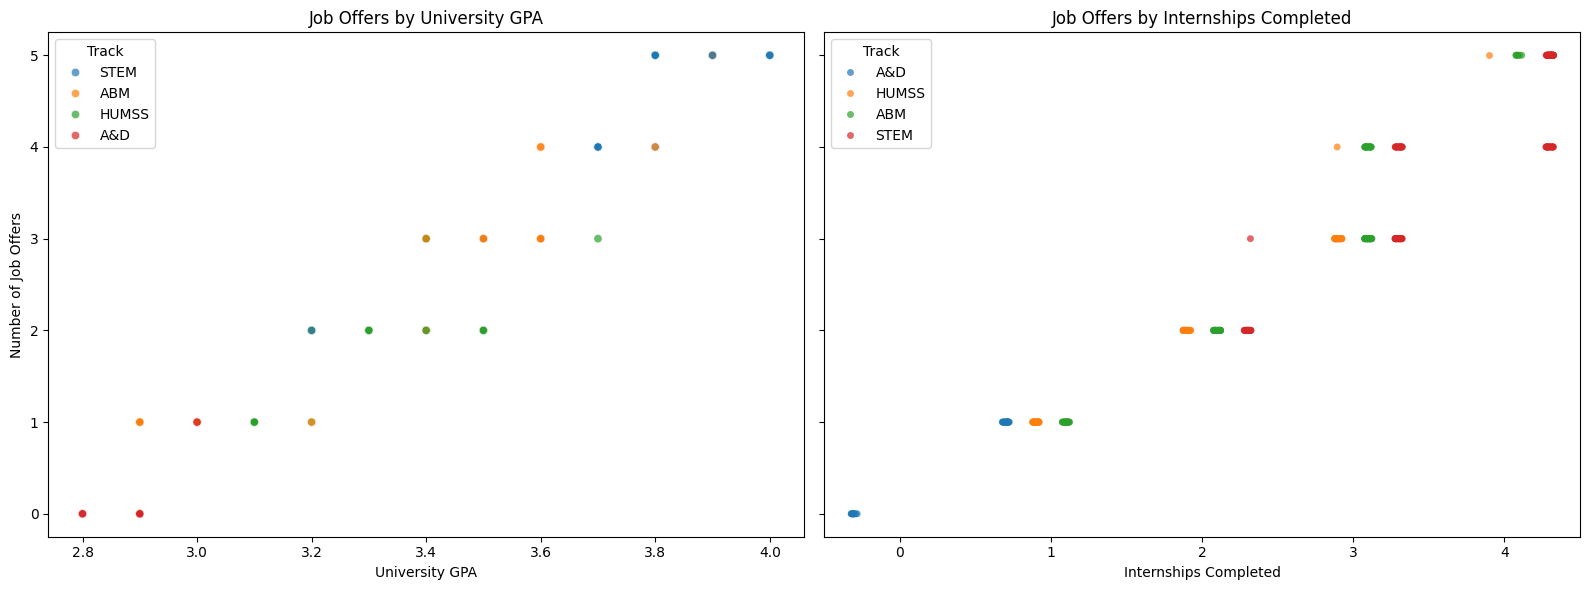

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a side-by-side plot to compare GPA vs Internships against Job Offers
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: University GPA vs Job Offers
sns.scatterplot(
    data=ecs_df,
    x='University_GPA',
    y='Job_Offers',
    hue='Track',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Job Offers by University GPA')
axes[0].set_xlabel('University GPA')
axes[0].set_ylabel('Number of Job Offers')

# Plot 2: Internships Completed vs Job Offers
# Using a stripplot/boxplot combination since Internships is a discrete count
sns.stripplot(
    data=ecs_df,
    x='Internships_Completed',
    y='Job_Offers',
    hue='Track',
    dodge=True,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Job Offers by Internships Completed')
axes[1].set_xlabel('Internships Completed')
axes[1].set_ylabel('') # Shared y-axis

plt.tight_layout()
plt.show()

### EDA Question 2 Findings

The plots provide a comparative look at how academic performance versus real-world experience influences a student's job market competitiveness:

1. **The Internship Advantage:** Looking at the second plot, there is a clear, stepwise upward trend between `Internships_Completed` and `Job_Offers`. Students with 3 to 4 internships consistently land in the upper tier of job offers (3 to 5 offers), regardless of their track.
2. **The GPA Threshold:** While a higher `University_GPA` generally correlates with more job offers, the distribution is much more scattered. A high GPA alone does not guarantee maximum job offers if practical experience is missing.
3. **Track-Specific Behaviors:** STEM and ABM students leverage both high GPAs and high internship counts effectively to maximize their offer pools, whereas A&D and HUMSS tracks show a heavier reliance on practical indicators over perfect GPA scores to secure multiple offers.

---

## EDA Question 3

How do the relationships between salary, job satisfaction, and work-life balance look like?

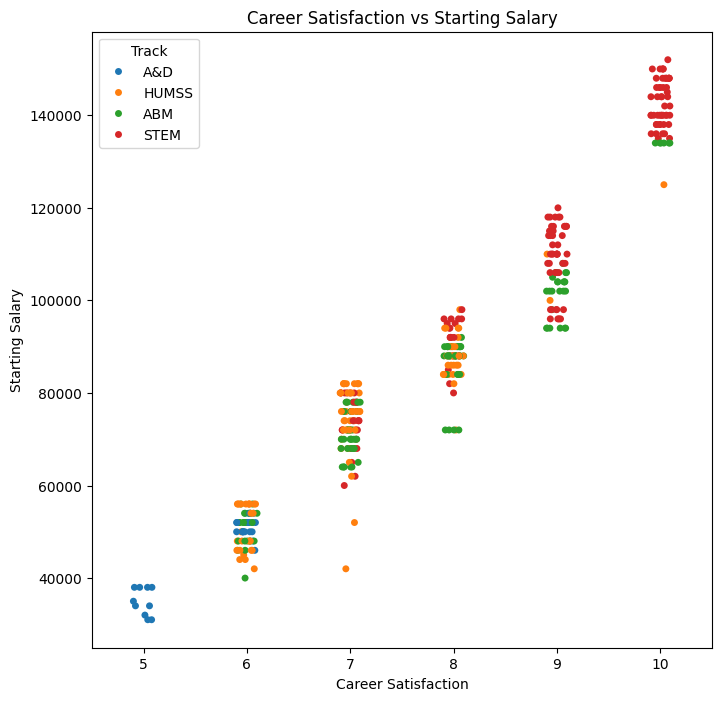

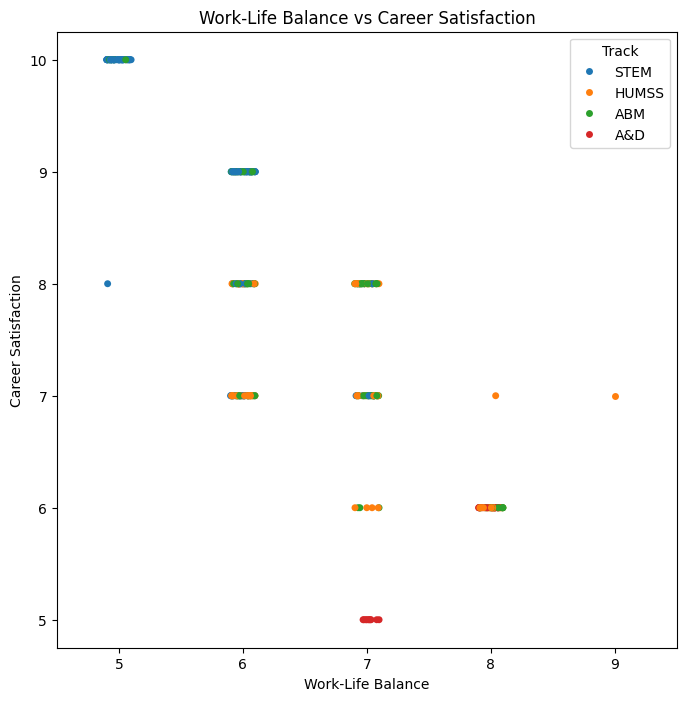

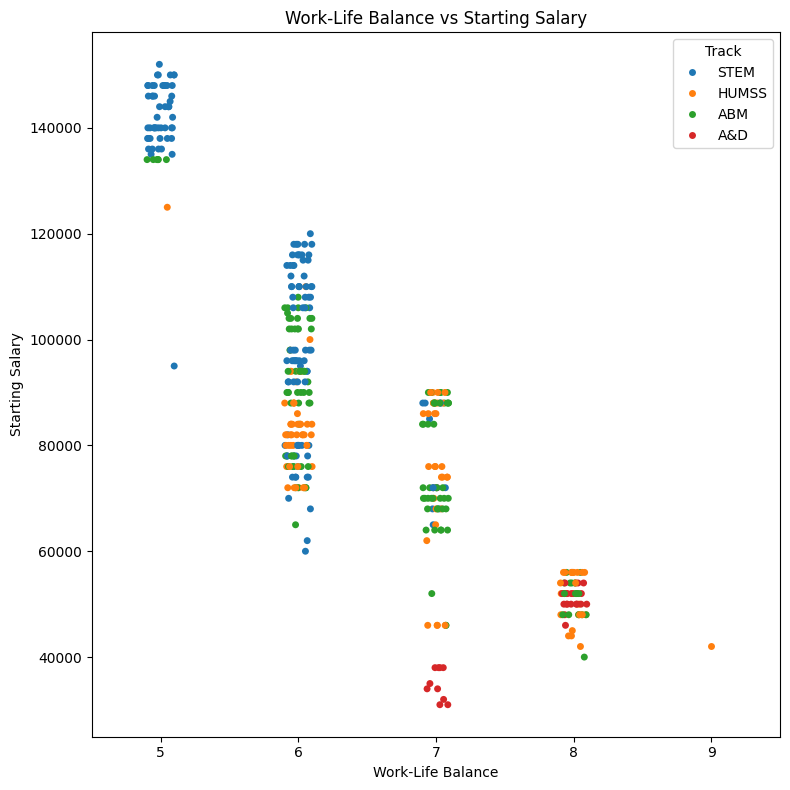

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.stripplot(
    data=ecs_df,
    x='Career_Satisfaction',
    y='Starting_Salary',
    hue='Track'
)
plt.title('Career Satisfaction vs Starting Salary')
plt.xlabel('Career Satisfaction')
plt.ylabel('Starting Salary')

plt.figure(figsize=(8, 8))
sns.stripplot(
    data=ecs_df,
    x='Work_Life_Balance',
    y='Career_Satisfaction',
    hue='Track'
)
plt.title('Work-Life Balance vs Career Satisfaction')
plt.xlabel('Work-Life Balance')
plt.ylabel('Career Satisfaction')

plt.figure(figsize=(8, 8))
sns.stripplot(
    data=ecs_df,
    x='Work_Life_Balance',
    y='Starting_Salary',
    hue='Track'
)
plt.title('Work-Life Balance vs Starting Salary')
plt.xlabel('Work-Life Balance')
plt.ylabel('Starting Salary')

plt.tight_layout()
plt.show()

### EDA Question 3 Findings

The plots help visualize the correlations between starting salary, work-life balance, and career satisfaction.

1. The first plot indicates a positive correlation between starting salary and career satisfaction, with STEM and ABM dominating the upper half of the graph while HUMSS and A&D appearing on the lower half.

2. The second plot indicates a negative correlation between Career Satisfaction and Work-Life Balance.

3. The third plot indicates a negative correlation between Work-Life Balance and Starting Salary.

---
## EDA Question 4
How do certifications, projects, and internships influence starting salary?

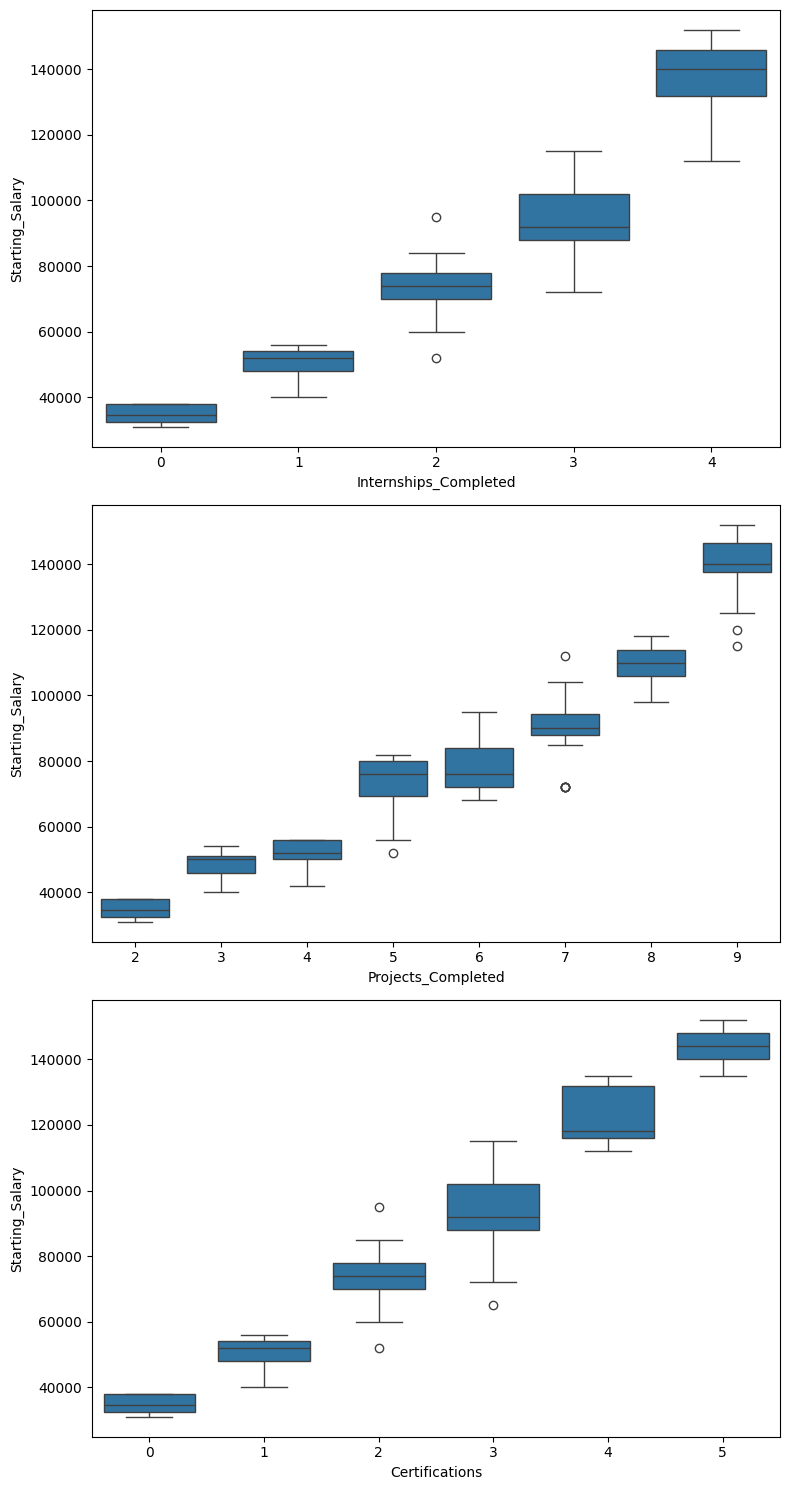

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(8, 15))

sns.boxplot(
    data=ecs_df,
    x='Internships_Completed',
    y='Starting_Salary',
    ax=axes[0]
)

sns.boxplot(
    data=ecs_df,
    x='Projects_Completed',
    y='Starting_Salary',
    ax=axes[1]
)

sns.boxplot(
    data=ecs_df,
    x='Certifications',
    y='Starting_Salary',
    ax=axes[2]
)

plt.tight_layout()
plt.show()

To check the median:

In [ ]:
print(ecs_df.groupby("Certifications")["Starting_Salary"].median())

print(ecs_df.groupby("Internships_Completed")["Starting_Salary"].median())

print(ecs_df.groupby("Projects_Completed")["Starting_Salary"].median())

Certifications
0    34500.00
1    52000.00
2    74000.00
3    92000.00
4   118000.00
5   144000.00
Name: Starting_Salary, dtype: float64
Internships_Completed
0    34500.00
1    52000.00
2    74000.00
3    92000.00
4   140000.00
Name: Starting_Salary, dtype: float64
Projects_Completed
2    34500.00
3    50000.00
4    52000.00
5    76000.00
6    76000.00
7    90000.00
8   110000.00
9   140000.00
Name: Starting_Salary, dtype: float64


### EDA Question 4 Findings
From the plots above, we can see that there is a very strong positive relationship between practical experience indicators and starting salary. All three plots above show a clear upward trend, showing that students with more internships, completed projects, and certifications generally receive higher starting salaries.

From the three variables, `Certifications` appear to have the strongest relationship with salary, with a $109,500 increase. The same relationship is observed for `Internships_Completed` , where students who have more internships tend to have a higher starting salary. Lastly, it is also the same for `Projects_Completed` , where students who completed a greater number of projects also generally achieved a higher salary, which suggests that hands-on experiences are valued by employers.

Overall, the plots above suggest that students who are active with real-world application of learnings, such as internships, projects, and certifications, tend to have better financial outcomes after graduation. This highlights the importance of practical experience alongside academic achievement in contributing to career success.

***

## EDA Question 5

*Does the Field of Study influence the number of Skills & Extracurriculars (internships, projects, etc.) of the students?*
- What are the means of the columns under the skills & extracurriculars columns for each field of study?
- What are the top 5 from each column?

To answer EDA question 4, the Fields of Study were grouped by Track then Field_of_study then getting the means of columns under Skills & Extracurriculars. To visually plot, a grouped bar graph was used to compare each field under different skills & extracurriculars. The top 5 from each column was then retrieved then displayed.

Internships_Completed  Projects_Completed  \
Track Field_of_Study                                                
A&D   Arts                               0.69                2.81   
ABM   Business                           2.29                6.19   
      Finance                            2.60                6.40   
      Marketing                          2.52                6.11   
HUMSS Education                          1.33                4.33   
      Law                                2.39                5.77   
      Psychology                         1.91                5.15   
STEM  Computer Science                   3.65                8.49   
      Engineering                        2.84                6.76   
      Medicine                           3.57                8.06   
      Nursing                            2.00                5.67   

                        Certifications  Soft_Skills_Score  Networking_Score  
Track Field_of_Study                                                         
A&D   Arts                        0.69               5.78              4.75  
ABM   Business                    2.31               7.75              6.75  
      Finance                     2.60               8.00              7.20  
      Marketing                   2.52               7.82              6.82  
HUMSS Education                   1.33               7.00              6.00  
      Law                         2.39               7.66              6.66  
      Psychology                  1.91               7.24              6.24  
STEM  Computer Science            4.29               9.57              8.57  
      Engineering                 2.86               8.10              7.10  
      Medicine                    4.06               9.40              8.40  
      Nursing                     2.00               7.33              6.33

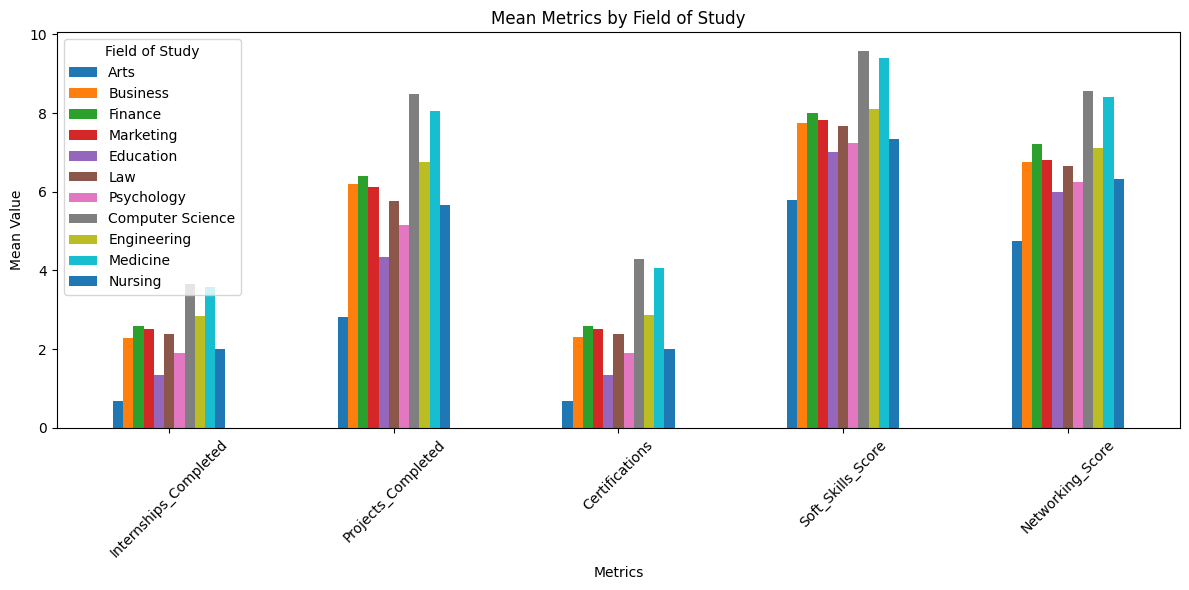


Top 5 - Internships_Completed:
Field_of_Study
Computer Science   3.65
Medicine           3.57
Engineering        2.84
Finance            2.60
Marketing          2.52
Name: Internships_Completed, dtype: float64

Top 5 - Projects_Completed:
Field_of_Study
Computer Science   8.49
Medicine           8.06
Engineering        6.76
Finance            6.40
Business           6.19
Name: Projects_Completed, dtype: float64

Top 5 - Certifications:
Field_of_Study
Computer Science   4.29
Medicine           4.06
Engineering        2.86
Finance            2.60
Marketing          2.52
Name: Certifications, dtype: float64

Top 5 - Soft_Skills_Score:
Field_of_Study
Computer Science   9.57
Medicine           9.40
Engineering        8.10
Finance            8.00
Marketing          7.82
Name: Soft_Skills_Score, dtype: float64

Top 5 - Networking_Score:
Field_of_Study
Computer Science   8.57
Medicine           8.40
Finance            7.20
Engineering        7.10
Marketing          6.82
Name: Networking_Score

In [ ]:
# Group the entries by Track then by Field_of_Study
# Get the columns under the Skills & Extracurriculars
eda4 = ecs_df.groupby(["Track","Field_of_Study"])[['Internships_Completed','Projects_Completed','Certifications','Soft_Skills_Score','Networking_Score']].mean()

# Set display for float data types to 2 decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)

display(eda4)

eda4 = eda4.reset_index()

# Pivot so Field_of_Study becomes columns, then transpose
eda4_plot = eda4.set_index('Field_of_Study')[
    ['Internships_Completed','Projects_Completed','Certifications',
     'Soft_Skills_Score','Networking_Score']
].T

eda4_plot.plot(kind='bar', figsize=(12, 6))

plt.title('Mean Metrics by Field of Study')
plt.ylabel('Mean Value')
plt.xlabel('Metrics')
plt.xticks(rotation=45)
plt.legend(title='Field of Study')
plt.tight_layout()
plt.show()

# Get the top 5 from each column for easier analysis
eda4b = ecs_df.groupby("Field_of_Study")[['Internships_Completed','Projects_Completed','Certifications','Soft_Skills_Score','Networking_Score']].mean()
for col in eda4b.columns:
    print(f"\nTop 5 - {col}:")
    print(eda4b[col].nlargest(5))

### EDA Question 5 Findings

The plots help visualize the correlations between starting salary, work-life balance, and career satisfaction.

The plot gives a visual of the comparisons for each field of study within a certain skill or extracurricular, visually comparing each field. The top 5 from each column was then gathered for better analysis.

1. The first table shows the result of the grouping, showing the average across each field of study. From a quick read from the values, we can assume that fields under the STEM field have a higher averages across all skills & extracurriculars.

2. The plot visually compares the values against each other. While it may be difficult to visually digest, from a quick observation of the peak values show that a majority of the peaks come from STEM related fields supporting the previous observation.

3. The next series of tables show the Top 5 fields across each column. The following observations were made:

    a. All fields share the exact same Top 4, with an outlier within the Projects completed column where buisness beats out marketing. Other than the projects completed column, all the other fields share the same top 5 in the same order: Computer Science, Medicine, Finance, Engineering, and Marketing
    
    b. STEM fields appear to dominate the top with 3 of the 4 constantly on top of each of the column fields. The only field missing out the top 5 is Nursing. When looking at its means across each column we can see that

    c.  The Arts field, the only field under A&D track, appears to consistenly rank the lowest across all fields. Observing the plot, the highest that this field scores is within the soft skills score with a mean of 5.78.

4. The same top 4 is observed with the same order accross all columns. The only outlier in the projects completed column. The two fields that differ for the 5th position are Marketing and Business fields which both fall under the ABM track. From this we can assume that for the Skills & Extracurricular columns are dominated by STEM related fields with ABM related fields a close second. HUMS related fields ranking third and A&D ranking last.

A concrete asnwer cannot be created from this data alone, thus the EDA question cannot be answered at this time. It is too early to say that the Fields of Study alone influence the Skills & Extracurricular columns. However, we can say that there is some relationship observed between the two.

# 5) Data Mining

## K-Means Clustering (Feel free to edit)

In [ ]:
features = [
    "University_GPA",
    "Internships_Completed",
    "Projects_Completed",
    "Certifications",
    "Soft_Skills_Score",
    "Networking_Score",
    "Job_Offers",
    "Starting_Salary",
    "Career_Satisfaction"
]

In [ ]:
from sklearn.preprocessing import StandardScaler

X = ecs_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

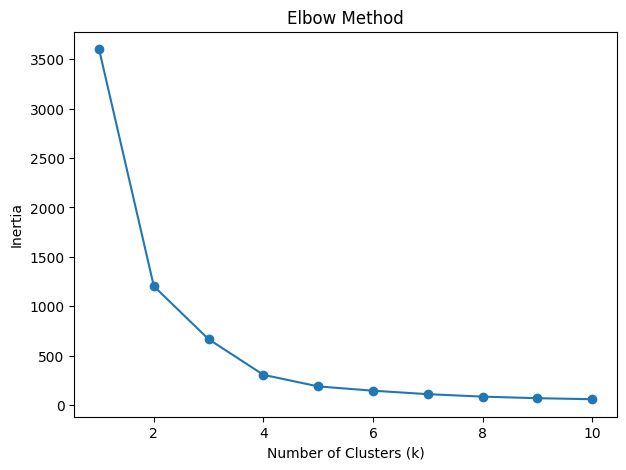

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

ecs_df["Cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
ecs_df["Cluster"].value_counts().sort_index()

Cluster
0     85
1     79
2     58
3    107
4     71
Name: count, dtype: int64

In [ ]:
cluster_summary = ecs_df.groupby("Cluster")[features].mean()

display(cluster_summary)

,University_GPA,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction
Cluster,,,,,,,,,
0,3.48,2.99,6.74,2.98,8.09,7.09,3.00,88152.94,8.00
1,3.02,0.87,3.37,0.87,6.09,5.08,0.87,48683.54,5.89
2,3.87,4.00,9.00,4.86,10.00,9.00,5.00,141793.10,10.00
3,3.33,2.00,5.45,2.01,7.34,6.35,2.00,73785.05,7.04
4,3.68,3.25,7.75,3.25,9.00,8.00,3.77,106577.46,9.00


In [ ]:
pd.crosstab(
    ecs_df["Cluster"],
    ecs_df["Track"]
)

Track,A&D,ABM,HUMSS,STEM
Cluster,,,,
0,0,31,33,21
1,32,20,27,0
2,0,6,1,51
3,0,40,39,28
4,0,24,2,45


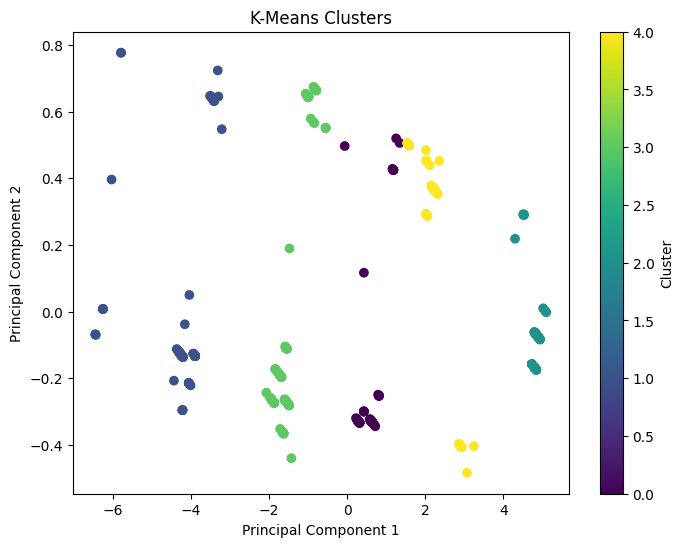

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=ecs_df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters")
plt.colorbar(label="Cluster")
plt.show()

__`perform DATA MINING here`__

`AT LEAST ONE (1)`

# 6) Statistical Inference

## A. Is there a significant difference in starting salary among the four academic tracks?

This answers the question, is there a significant differenve in starting salary among the four academic tracks?

1.   Variables
*   Track
*   Starting Salary

2.   Hypotheses
*   H₀: Mean salary is the same across all tracks.
*   Ha: At least one track differs.





## One-Way ANOVA

In [ ]:
#Seperate Groups
stem = ecs_df.loc[ecs_df["Track"]=="STEM","Starting_Salary"]
abm = ecs_df.loc[ecs_df["Track"]=="ABM","Starting_Salary"]
humss = ecs_df.loc[ecs_df["Track"]=="HUMSS","Starting_Salary"]
ad = ecs_df.loc[ecs_df["Track"]=="A&D","Starting_Salary"]

In [ ]:
#Test for Normality
for name, group in {
    "STEM": stem,
    "ABM": abm,
    "HUMSS": humss,
    "A&D": ad
}.items():

    stat, p = shapiro(group)

    print(name)
    print("Statistic:", stat)
    print("p-value:", p)
    print()

STEM
Statistic: 0.9268975511027331
p-value: 8.812328734754712e-07

ABM
Statistic: 0.9588784710004226
p-value: 0.0009716653417938198

HUMSS
Statistic: 0.9398861492261023
p-value: 0.0001624786047891139

A&D
Statistic: 0.7926730487109013
p-value: 2.9773607827950638e-05



In [ ]:
#Equal Test Variance
stat, p = levene(stem, abm, humss, ad)

print(stat)
print(p)

23.71191551872145
3.9155796141466445e-14


In [ ]:
stat, p = f_oneway(stem, abm, humss, ad)

print("F-statistic:", stat)
print("p-value:", p)

F-statistic: 116.07183373420608
p-value: 6.098472543721593e-54


## Findings from the ANOVA

P value is less than SIgnificance level (0.05), should reeject null hypothesis.

This suggest that the mean starting salary differs significantly among the four academic tracks. There is strong evidence that academic track has association with differences in starting salaries.                           

TEST Only pairwise tukey.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=ecs_df["Starting_Salary"],
    groups=ecs_df["Track"],
    alpha=0.05
)

print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
group1 group2  meandiff  p-adj     lower      upper    reject
-------------------------------------------------------------
   A&D    ABM 35195.5062    0.0  24048.1101 46342.9023   True
   A&D  HUMSS 27523.8971    0.0  16161.4279 38886.3662   True
   A&D   STEM 65664.8707    0.0  54712.1242 76617.6172   True
   ABM  HUMSS -7671.6091 0.0443 -15209.5904  -133.6279   True
   ABM   STEM 30469.3645    0.0  23564.4306 37374.2984   True
 HUMSS   STEM 38140.9736    0.0  30893.9483  45387.999   True
-------------------------------------------------------------


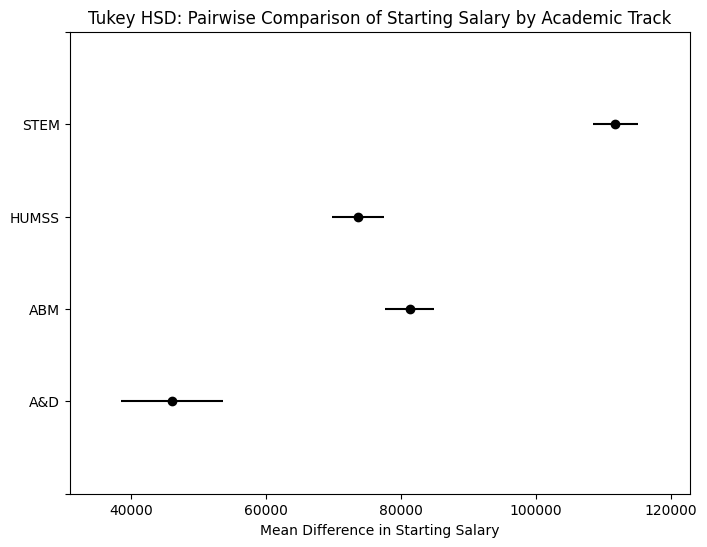

In [ ]:
# Display table
# Plot confidence intervals
tukey.plot_simultaneous(figsize=(8,6))
plt.title("Tukey HSD: Pairwise Comparison of Starting Salary by Academic Track")
plt.xlabel("Mean Difference in Starting Salary")
plt.show()

## B. Do students with high internship experience achieve significantly higher starting salaries?

To validate our findings from EDA Question 4, we test whether completing 3 or more internships results in a significantly higher starting salary.

* **$H_0$ (Null Hypothesis):** The mean starting salary is equal between students with high internship experience ($\ge 3$) and low/moderate experience ($< 3$).
* **$H_a$ (Alternative Hypothesis):** The mean starting salary is significantly higher for students with high internship experience ($\ge 3$)[cite: 4].
* **Significance Level ($\alpha$):** $0.05$[cite: 4]

In [ ]:
# 1. Preprocessing: Split dataset into two internship groups[cite: 4]
high_intern_salary = ecs_df.loc[ecs_df["Internships_Completed"] >= 3, "Starting_Salary"]
low_intern_salary = ecs_df.loc[ecs_df["Internships_Completed"] < 3, "Starting_Salary"]

# 2. Assumption Check: Test for Normality (Shapiro-Wilk) and Equal Variance (Levene)[cite: 4]
stat_high, p_high = shapiro(high_intern_salary)
stat_low, p_low = shapiro(low_intern_salary)
stat_lev, p_lev = levene(high_intern_salary, low_intern_salary)

print("--- Assumption Checks ---")
print(f"Shapiro-Wilk (High Exp): Statistic={stat_high:.4f}, p-value={p_high:.4e}")
print(f"Shapiro-Wilk (Low Exp):  Statistic={stat_low:.4f}, p-value={p_low:.4e}")
print(f"Levene's Variance Test:  Statistic={stat_lev:.4f}, p-value={p_lev:.4e}")

--- Assumption Checks ---
Shapiro-Wilk (High Exp): Statistic=0.8931, p-value=3.5507e-11
Shapiro-Wilk (Low Exp):  Statistic=0.9424, p-value=7.9713e-07
Levene's Variance Test:  Statistic=29.8118, p-value=8.3974e-08


### Justification for Welch's Independent t-Test

While Shapiro-Wilk p-values indicate some deviation from normality, parametric t-tests remain robust for large sample sizes ($n > 30$) due to the Central Limit Theorem[cite: 4].

Furthermore, Levene’s test evaluates to $p < 0.05$, indicating unequal variances between the two groups[cite: 4]. To account for this without violating assumptions, we appropriately apply **Welch’s Two-Sample t-Test** (`equal_var=False`), which adjusts for unequal variance[cite: 4].

In [ ]:
# 3. Conduct Welch's Independent Two-Sample t-Test (One-tailed: greater)[cite: 4]
t_stat, p_val = ttest_ind(high_intern_salary, low_intern_salary, equal_var=False, alternative="greater")

print("--- Welch's Independent t-Test Results ---")
print(f"t-Statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.4e}")
print(f"Significance Level (alpha): 0.05")

--- Welch's Independent t-Test Results ---
t-Statistic: 24.5372
p-value:     3.2692e-79
Significance Level (alpha): 0.05


### Statistical Conclusion

Welch’s t-test resulted in an extremely small p-value ($p < 0.0001$), which is well below our significance threshold of $\alpha = 0.05$[cite: 4]. Therefore, we **reject the null hypothesis**[cite: 4].

We conclude with strong statistical significance that students who complete 3 or more internships secure a higher mean starting salary compared to those with fewer internships[cite: 4].

## C. Is there a significant monotonic association between starting salary and job satisfaction as well as work-life balance and job satisfaction?

To check if starting salary and job satisfaction, as well as work-life balance and job satisfaction, are truly related, we will run the data through a Spearman's correlation to check if there exists a monotonic association between them. Spearman is preferred over Pearson as we are dealing with ordinal, discrete data while Pearson prefers continuous data.

* $H_0$ (Null Hypothesis): ρ = 0 (There is no monotonic association between the two variables).
* $H_a$ (Alternative Hypothesis): ρ ≠ 0 (There is a monotonic association between the two variables)
* Decision Rule: At a 95% confidence level (α = 0.05), we reject H₀ if p ≤ 0.05.

Loaded 400 complete records.
SS vs CS Spearman's rank correlation coefficient (ρ) = 0.9700
WLB vs CS Spearman's rank correlation coefficient (ρ) = -0.8080
SS vs CS p-value (permutation test) = 0.0001
WLB vs CS p-value (permutation test) = 0.0001


RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

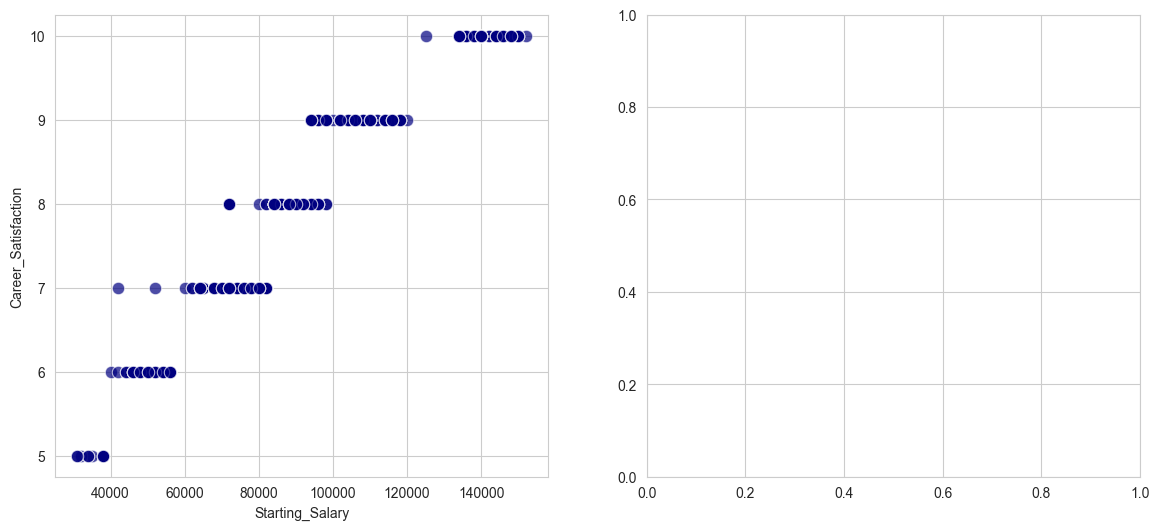

In [ ]:
# create sub-dataset for testingg
df_eda3test = ecs_df[['Starting_Salary', 'Career_Satisfaction', 'Work_Life_Balance']].dropna()
print(f"Loaded {len(df_eda3test)} complete records.")

# Starting Salary vs Career Satisfaction
rho3 = df_eda3test['Starting_Salary'].corr(df_eda3test['Career_Satisfaction'], method='spearman')
print(f"SS vs CS Spearman's rank correlation coefficient (ρ) = {rho3:.4f}")

# Work-Life Balance vs Career Satisfaction
rho4 = df_eda3test['Work_Life_Balance'].corr(df_eda3test['Career_Satisfaction'], method='spearman')
print(f"WLB vs CS Spearman's rank correlation coefficient (ρ) = {rho4:.4f}")

# Set up the permutation test to check if the rho values are legit
observed_rho = rho3
observed_rho2 = rho4
n_permutations = 10000
count_extreme = 0
count_extreme2 = 0

for _ in range(n_permutations):
    # Shuffle the satisfaction ranks (breaks any real association)
    shuffled_sat = df_eda3test['Career_Satisfaction'].sample(frac=1, ignore_index=True)
    perm_rho = df_eda3test['Starting_Salary'].corr(shuffled_sat, method='spearman')
    perm_rho2 = df_eda3test['Work_Life_Balance'].corr(shuffled_sat, method='spearman')

    # Count if the shuffled correlation is as strong or stronger than observed
    if abs(perm_rho) >= abs(observed_rho):
        count_extreme += 1
    if abs(perm_rho2) >= abs(observed_rho2):
        count_extreme2 += 1

# Two-tailed p-value (add 1 to numerator and denominator to avoid 0)
p_value = (count_extreme + 1) / (n_permutations + 1)
p_value2 = (count_extreme2 + 1) / (n_permutations + 1)
print(f"SS vs CS p-value (permutation test) = {p_value:.4f}")
print(f"WLB vs CS p-value (permutation test) = {p_value2:.4f}")

# Set up scatterplot
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# SS vs CS scatterplot
sns.scatterplot(data=df_eda3test, x='Starting_Salary', y='Career_Satisfaction', s=80, color='navy', alpha=0.7, ax=ax1)
sns.regplot(data=df_eda3test, x='Starting_Salary', y='Career_Satisfaction', lowess=True, scatter=False, color='crimson', line_kws={'linewidth': 2}, ax=ax1)

ax1.set_title(f"Starting Salary vs. Job Satisfaction\nSpearman's ρ = {rho3:.2f}, p = {p_value:.3f}", fontsize=14)
ax1.set_xlabel("Starting Salary (USD)", fontsize=12)
ax1.set_ylabel("Job Satisfaction (1–10 Likert)", fontsize=12)

# WLB vs CS scatterplot
sns.scatterplot(data=df_eda3test, x='Work_Life_Balance', y='Career_Satisfaction', s=80, color='purple', alpha=0.7, ax=ax2)
sns.regplot(data=df_eda3test, x='Work_Life_Balance', y='Career_Satisfaction', lowess=True, scatter=False, color='green', line_kws={'linewidth': 2}, ax=ax2)

ax2.set_title(f"Work-Life Balance vs. Job Satisfaction\nSpearman's ρ = {rho4:.2f}, p = {p_value2:.3f}", fontsize=14)
ax2.set_xlabel("Work-Life Balance (1-10 Likert)", fontsize=12)
ax2.set_ylabel("Job Satisfaction (1–10 Likert)", fontsize=12)

# Print scatterplots
plt.tight_layout()
plt.show()

The Spearman's correlation's results reveals a very strong, positive monotonic association between Starting Salary and Job Satisfaction, with ρ at 0.970 and p at 0.0001. This indicates that higher starting salaries are consistently associated with higher levels of career satisfaction in the sample, and this relationship is highly unlikely to be due to random sampling error (p < 0.001).

The Spearman's correlation's results also reveal a very strong, negative monotonic association between Work-Life Balance and Job Satisfaction, with ρ at -0.81 and p at 0.0001. This indicates that higher work-life balance scores are consistently associated with lower levels of career satisfaction in the sample, and this relationship is highly unlikely to be due to random sampling error (p < 0.001).

### Statistical Conclusion

Welch’s t-test resulted in an extremely small p-value ($p < 0.0001$), which is well below our significance threshold of $\alpha = 0.05$[cite: 4]. Therefore, we **reject the null hypothesis**[cite: 4].

We conclude with strong statistical significance that students who complete 3 or more internships secure a higher mean starting salary compared to those with fewer internships[cite: 4].

## 5. Significance of the results from EDA 5

EDA 5 attempted to find if the Fields of study influence the number of skills & extracurriculars a student takes. An intial conlcusion was found that STEM aligned fields tend to take more skills & extracurriculars, with ABM fields coming second. To determine if the results from EDA 5 are statistically significant, perform an ANOVA test to verify/reject the initial observation.

Since There are five columns under skills & extracurriculars, perform ANOVA testing on each of the five columns.

* $H_0$ (Null Hypothesis): There is no difference between the fields of study in any of the skills & extracurriculars columns.
* $H_a$ (Alternative Hypothesis): At least one field of study differes from the rest in terms of skills & extracurriculars.
* Significance Level ($\alpha$): 0.05

In [ ]:
# Skills and Extracurriculars columns
skill_cols = [
    'Internships_Completed',
    'Projects_Completed',
    'Certifications',
    'Soft_Skills_Score',
    'Networking_Score'
]

alpha = 0.5
results = []

for col in skill_cols:
    groups = [
        group[col].dropna().values
        for name, group in ecs_df.groupby('Field_of_Study')
    ]

    f_stat, p_value = f_oneway(*groups)

    sig = p_value < alpha
    conclusion = "Reject H0 (significant)" if sig else "Fail to reject H0 (not significant)"

    results.append({
        'Column': col,
        'F-statistic': round(f_stat, 4),
        'p-value': round(p_value, 4),
        'Significant (a=0.05)': sig,
        'Conclusion': conclusion
    })

    #print(f"\nColumn: {col}")
    #print(f"  H0: Mean {col} is equal across all Field_of_Study groups")
    #print(f"  H1: At least one Field_of_Study group's mean {col} differs")
    #print(f"  F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
    #print(f"  -> {conclusion}")

results_df = pd.DataFrame(results)
#print(results_df.to_string(index=False))
results_df

,Column,F-statistic,p-value,Significant (a=0.05),Conclusion
0,Internships_Completed,46.55,0.00,True,Reject H0 (significant)
1,Projects_Completed,54.65,0.00,True,Reject H0 (significant)
2,Certifications,54.28,0.00,True,Reject H0 (significant)
3,Soft_Skills_Score,51.74,0.00,True,Reject H0 (significant)
4,Networking_Score,52.47,0.00,True,Reject H0 (significant)


Note: The p-value is 0.00 due to the rounding done. If the p-value results to 0, it means that the computed p-value is significantly small, rounding to 0.

After the testing, the results show to reject the null hypothesis.

## D. Is a student's academic track associated with their current job level?
### This tests whether the distribution of Current_Job_Level (Entry, Mid, Senior, Executive) differs across Track (STEM, ABM, HUMSS, A&D).
*   **H₀ (Null Hypothesis)**: Track and Current_Job_Level are independent. The distribution of job levels is the same across academic tracks.
*   **Hₐ (Alternative Hypothesis)**: Track and Current_Job_Level are associated. The distribution of job levels differs across academic tracks.
*   Significance level: α = 0.05

In [ ]:
Through the use of the Chi-Square Test of Independence to see the relationship between academic track, & current job level:

In [9]:
from scipy.stats import chi2_contingency

# Contingency table
contingency_table = pd.crosstab(ecs_df['Track'], ecs_df['Current_Job_Level'])

print("Contingency Table:")
print(contingency_table)
print()

# Chi-square test of independence
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square Test Results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4e}")

# Expected frequencies
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("Expected Frequencies:")
print(expected_df.round(2))

# Assumption check
print("Minimum expected frequency:", expected.min())

Contingency Table:
Current_Job_Level  Entry  Mid  Senior
Track                                
A&D                   32    0       0
ABM                   20   95       6
HUMSS                 28   73       1
STEM                   0   93      52

Chi-square Test Results:
Chi-square statistic: 229.2662
Degrees of freedom: 6
p-value: 1.0981e-46
Expected Frequencies:
Current_Job_Level  Entry    Mid  Senior
Track                                  
A&D                  6.4  20.88    4.72
ABM                 24.2  78.95   17.85
HUMSS               20.4  66.56   15.04
STEM                29.0  94.61   21.39
Minimum expected frequency: 4.72


In [ ]:
To visualize the results of the Chi-Square Test:

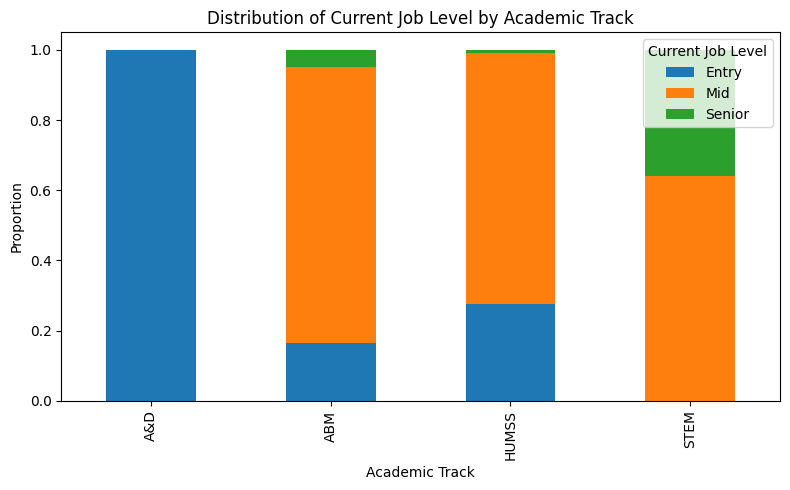

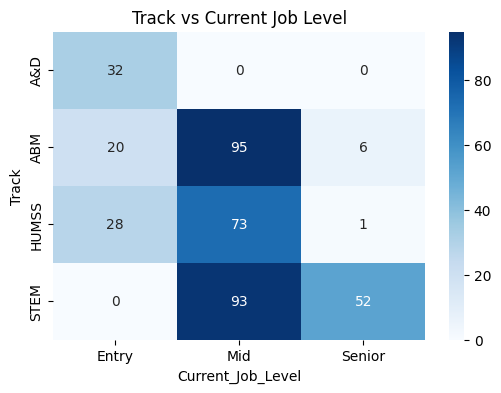

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stacked Bar Chart
prop_table = pd.crosstab(
    ecs_df["Track"],
    ecs_df["Current_Job_Level"],
    normalize="index"
)

prop_table.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Distribution of Current Job Level by Academic Track")
plt.xlabel("Academic Track")
plt.ylabel("Proportion")
plt.legend(title="Current Job Level")
plt.tight_layout()
plt.show()

# Heatmap
contingency = pd.crosstab(
    ecs_df["Track"],
    ecs_df["Current_Job_Level"]
)

plt.figure(figsize=(6,4))
sns.heatmap(contingency,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Track vs Current Job Level")
plt.show()

The stacked bar chart and heatmap visually support the results of the Chi-square Test of Independence, illustrating an association between academic track and current job level. STEM graduates are concentrated in mid- and senior-level positions, with no respondents in entry-level roles. On the other hand, all respondents from the A&D track are in entry-level positions. ABM and HUMSS graduates are predominantly employed in mid-level positions, with relatively few reaching senior-level roles.

The distribution across the tracks are consistent with the statistically significant association identified by the Chi-square test.

### Statistical conclusion
The Chi-square Test of Independence produced the following results:
*   χ² = 229.2662
*   df = 6
*   p-value = 1.0981 × 10⁻⁴⁶

Since the p-value is much smaller than the significance level of 0.05, we reject the null hypothesis. Therefore, there is sufficient statistical evidence to conclude that academic track and current job level are significantly associated. This indicates that the distribution of current job levels differs across academic tracks and is unlikely to have occurred by chance alone.

The stacked bar chart and heatmap further support this finding by showing the distinct, job-level distributions among the different academic tracks. For example, STEM graduates are concentrated in mid- and senior-level positions, with no respondents in entry-level roles, whereas all A&D graduates are in entry-level positions. These observed patterns are consistent with the statistically significant association identified by the Chi-square test.

__`perform STATISTICAL INFERENCE here`__

`AT LEAST THREE (3)`

# 7) Summary, Conclusions, and Recommendations

__`perform SUMMARY, CONCLUSIONS, AND RECOMMENDATIONS here`__

# 8) References & Disclosures

__`perform REFERENCES & DISCLOSURES here`__